Cell 1 — Imports and load data:

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import harmonypy as hm
import os
import warnings
warnings.filterwarnings('ignore')

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=True)

# Load normalized/scaled data from Program 3
adata = sc.read_h5ad(os.path.expanduser("~/ATRT/Data/adata_normalized_scaled.h5ad"))
print(f"Loaded: {adata.n_obs} nuclei x {adata.n_vars} genes")
print(f"HVGs: {adata.var['highly_variable'].sum()}")
print(f"Raw counts in adata.raw: {adata.raw.n_vars} genes")

Loaded: 9604 nuclei x 36601 genes
HVGs: 2000
Raw counts in adata.raw: 36601 genes


Cell 2 — Run PCA:

In [2]:
# Run PCA on the HVG subset
sc.tl.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack')
print(f"PCA complete: {adata.obsm['X_pca'].shape[1]} components computed")

computing PCA
    with n_comps=50
    finished (0:00:01)
PCA complete: 50 components computed


Cell 3 — Elbow plot (Figure 2B):

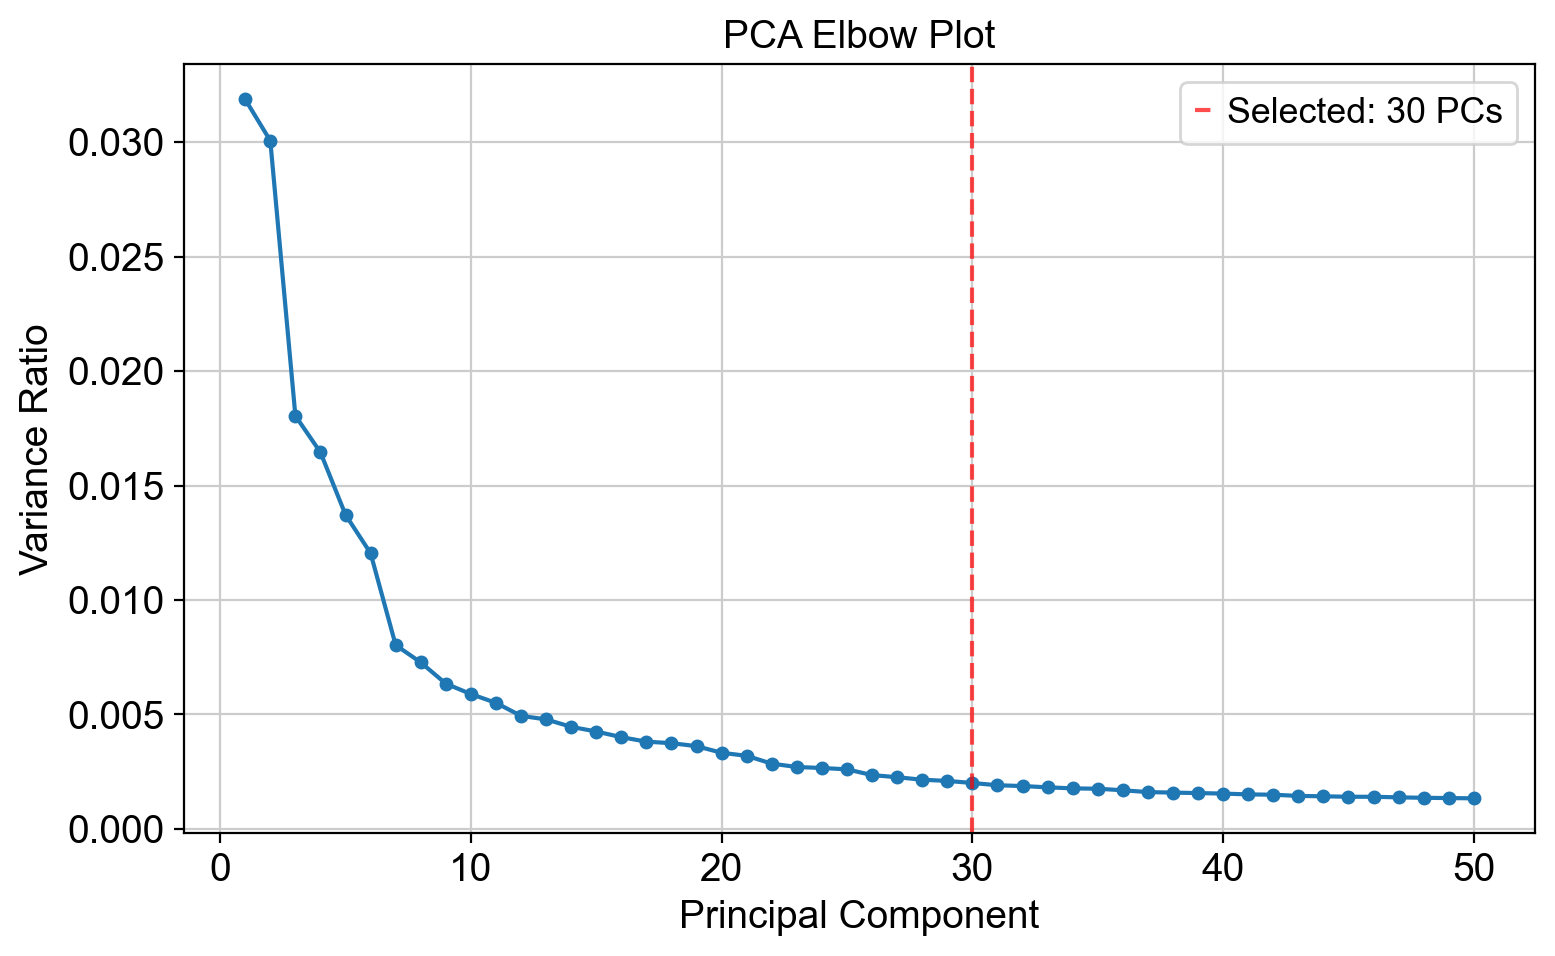


>>> FIGURE 2B: Saved to ~/ATRT/Data/Fig2B_elbow_plot.png
>>> Cumulative variance explained by 30 PCs: 21.7%
>>> REPORT NOTE: '30 PCs were retained for downstream analysis,
>>>   guided by the elbow plot of explained variance'


In [3]:
# ============================================================
# FIGURE FOR REPORT: Elbow plot of PCA variance → Figure 2B
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 51), adata.uns['pca']['variance_ratio'], 'o-', markersize=4)
ax.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Selected: 30 PCs')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Ratio')
ax.set_title('PCA Elbow Plot')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.expanduser("~/ATRT/Data/Fig2B_elbow_plot.png"), dpi=300, bbox_inches='tight')
plt.show()

# Print cumulative variance explained by 30 PCs
cumvar_30 = adata.uns['pca']['variance_ratio'][:30].sum() * 100
print(f"\n>>> FIGURE 2B: Saved to ~/ATRT/Data/Fig2B_elbow_plot.png")
print(f">>> Cumulative variance explained by 30 PCs: {cumvar_30:.1f}%")
print(f">>> REPORT NOTE: '30 PCs were retained for downstream analysis,")
print(f">>>   guided by the elbow plot of explained variance'")

Cell 4 — Pre-Harmony UMAP (to show batch effects):

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:14)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:08)


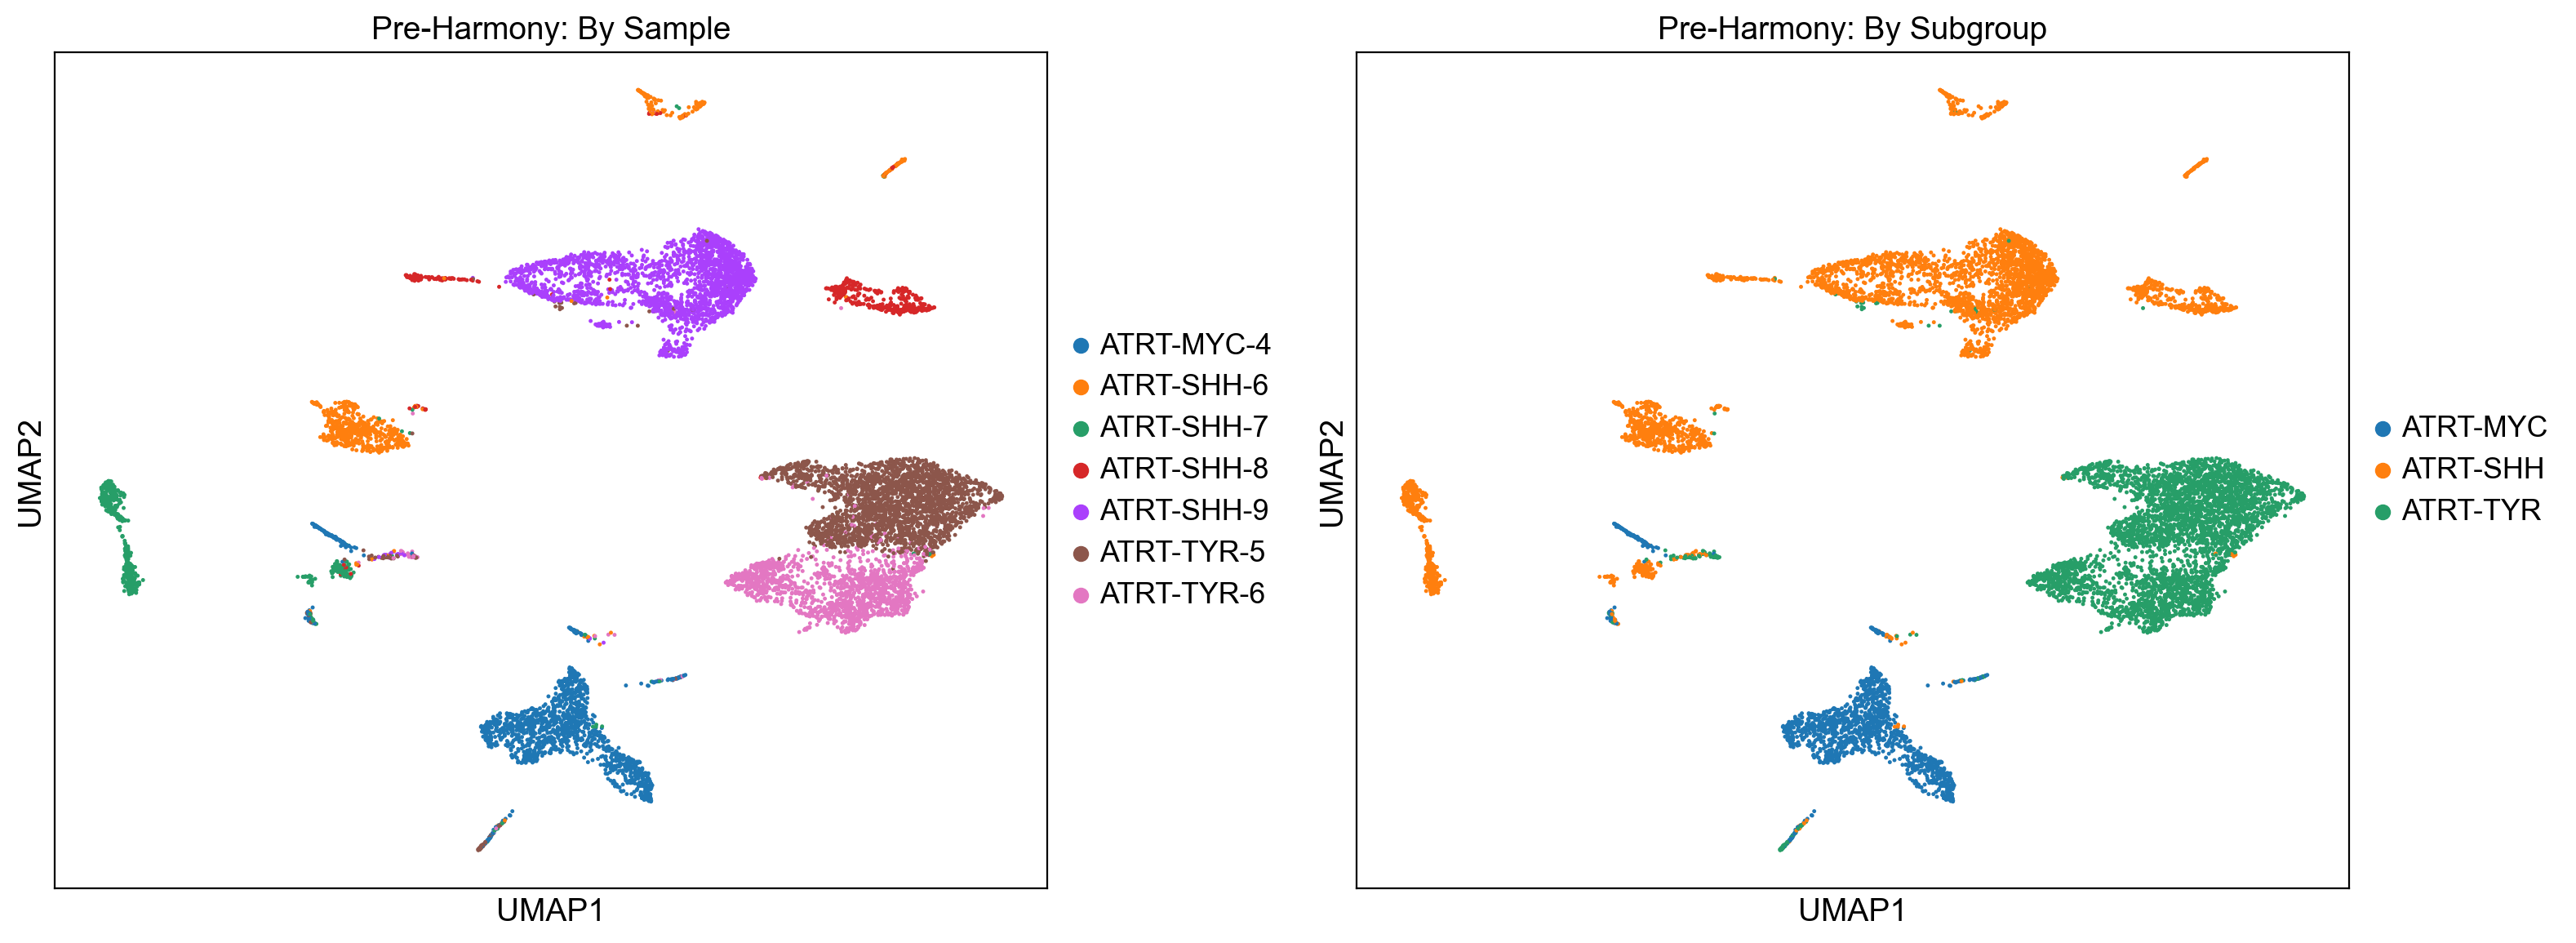


>>> Pre-Harmony UMAP saved to ~/ATRT/Data/UMAP_pre_harmony.png
>>> REPORT NOTE: Check if samples cluster by patient rather than biology


In [4]:
# Compute neighbors and UMAP BEFORE Harmony (to visualize batch effects)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata, min_dist=0.3, spread=1.0)

# Save pre-Harmony UMAP coordinates
adata.obsm['X_umap_uncorrected'] = adata.obsm['X_umap'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc.pl.umap(adata, color='sample', ax=axes[0], show=False, title='Pre-Harmony: By Sample')
sc.pl.umap(adata, color='subgroup', ax=axes[1], show=False, title='Pre-Harmony: By Subgroup')

plt.tight_layout()
plt.savefig(os.path.expanduser("~/ATRT/Data/UMAP_pre_harmony.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n>>> Pre-Harmony UMAP saved to ~/ATRT/Data/UMAP_pre_harmony.png")
print(">>> REPORT NOTE: Check if samples cluster by patient rather than biology")

Cell 5 — Run Harmony batch correction:

In [5]:
# Run Harmony on the PCA embedding, correcting for sample/patient
print("Running Harmony batch correction...")
harmony_out = hm.run_harmony(
    adata.obsm['X_pca'][:, :30],  # Use first 30 PCs
    adata.obs,
    'sample',                      # Correct for sample/patient
    theta=2,                       # Diversity penalty
    max_iter_harmony=10
)

# Store Harmony-corrected embedding
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr
print(f"Harmony complete: corrected embedding shape = {adata.obsm['X_pca_harmony'].shape}")

2026-04-03 15:21:18,400 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-04-03 15:21:18,401 - harmonypy - INFO -   Parameters:
2026-04-03 15:21:18,401 - harmonypy - INFO -     max_iter_harmony: 10
2026-04-03 15:21:18,401 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-03 15:21:18,401 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-03 15:21:18,402 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-03 15:21:18,402 - harmonypy - INFO -     nclust: 100
2026-04-03 15:21:18,402 - harmonypy - INFO -     block_size: 0.05
2026-04-03 15:21:18,403 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1.]
2026-04-03 15:21:18,403 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2.]
2026-04-03 15:21:18,404 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-03 15:21:18,404 - harmonypy - INFO -     verbose: True
2026-04-03 15:21:18,404 - harmonypy - INFO -     random_state: 0
2026-04-03 15:21:18,405 - harmonypy - INFO -   Data: 30 PCs × 9604 cells
2026-04-03 15

Running Harmony batch correction...


2026-04-03 15:21:20,279 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-04-03 15:21:20,540 - harmonypy - INFO - KMeans initialization complete.
2026-04-03 15:21:21,251 - harmonypy - INFO - Iteration 1 of 10
2026-04-03 15:21:22,838 - harmonypy - INFO - Iteration 2 of 10
2026-04-03 15:21:23,180 - harmonypy - INFO - Iteration 3 of 10
2026-04-03 15:21:23,569 - harmonypy - INFO - Iteration 4 of 10
2026-04-03 15:21:23,980 - harmonypy - INFO - Iteration 5 of 10
2026-04-03 15:21:24,377 - harmonypy - INFO - Converged after 5 iterations


Harmony complete: corrected embedding shape = (9604, 30)


Cell 6 — Post-Harmony UMAP:

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:08)


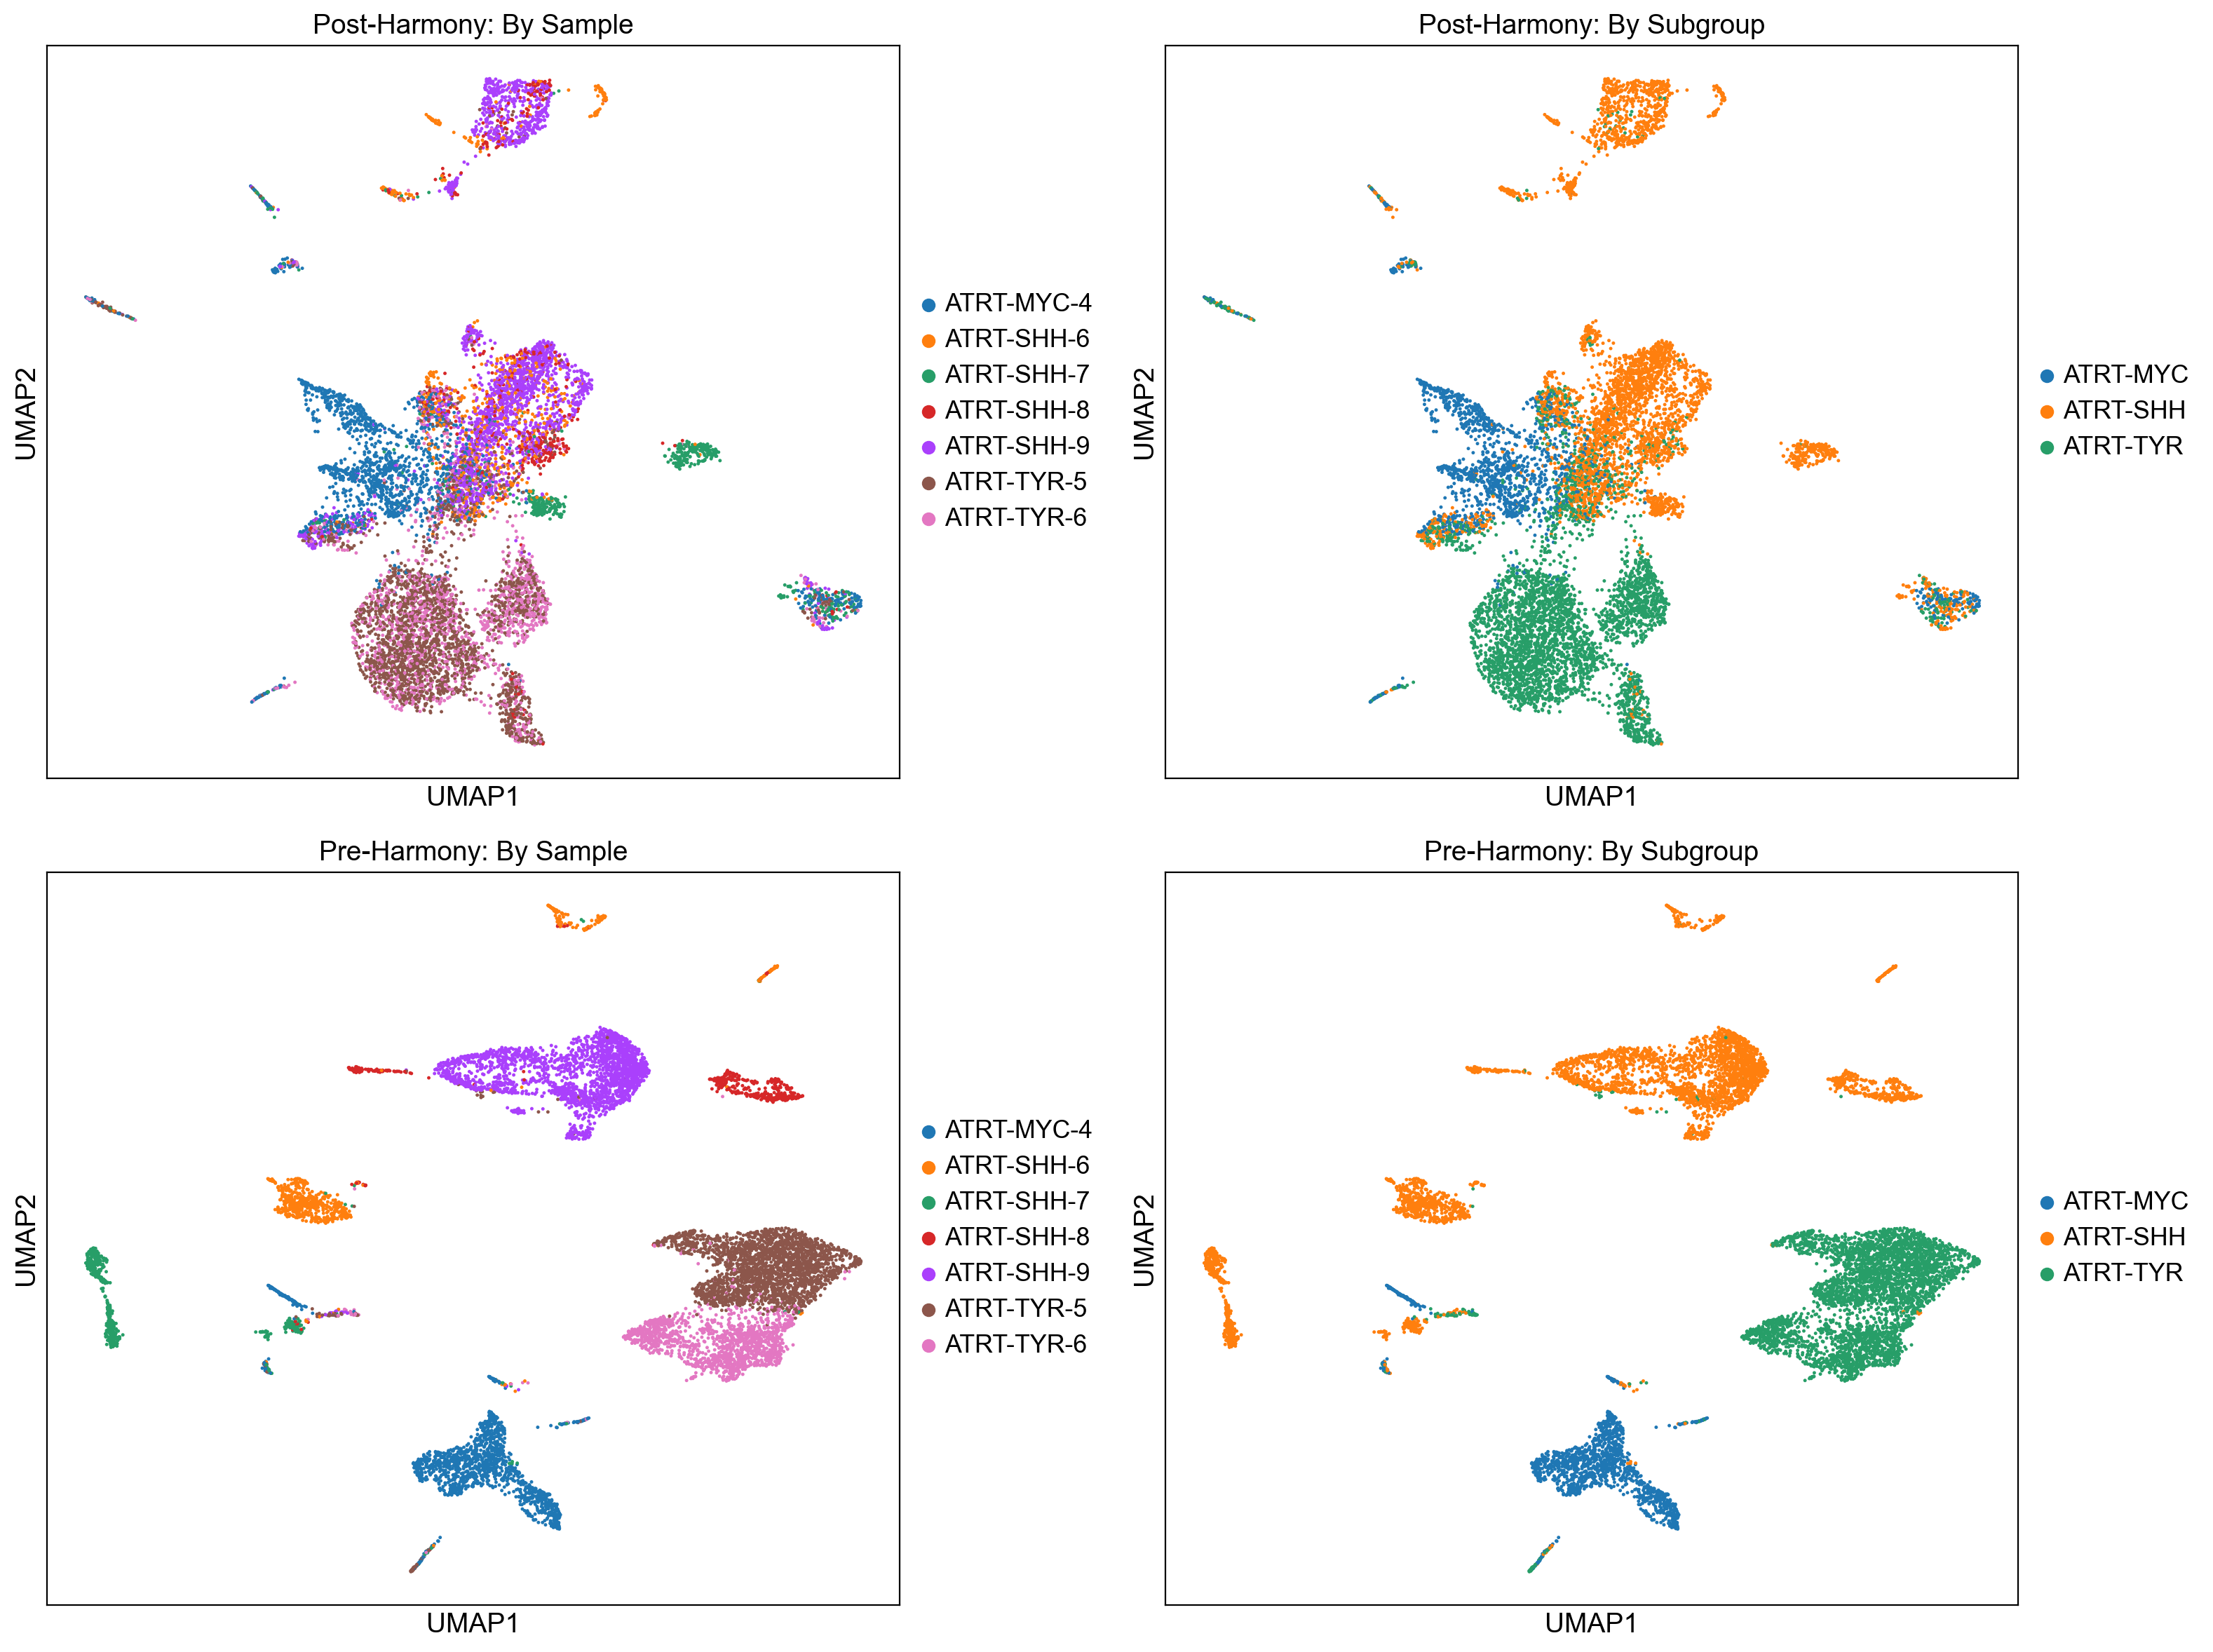


>>> FIGURE 2B: Harmony comparison saved to ~/ATRT/Data/Fig2B_harmony_comparison.png
>>> REPORT NOTE: 'Post-Harmony UMAP shows mixing of patient samples
>>>   within biologically coherent clusters, confirming successful integration'


In [6]:
# Recompute neighbors and UMAP using Harmony-corrected embedding
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, use_rep='X_pca_harmony')
sc.tl.umap(adata, min_dist=0.3, spread=1.0)

# ============================================================
# FIGURE FOR REPORT: Pre vs Post Harmony comparison
# Include in Figure 2B or as supplementary
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top row: Post-Harmony
sc.pl.umap(adata, color='sample', ax=axes[0][0], show=False, title='Post-Harmony: By Sample')
sc.pl.umap(adata, color='subgroup', ax=axes[0][1], show=False, title='Post-Harmony: By Subgroup')

# Bottom row: Pre-Harmony (use saved coordinates)
adata.obsm['X_umap_temp'] = adata.obsm['X_umap'].copy()
adata.obsm['X_umap'] = adata.obsm['X_umap_uncorrected']

sc.pl.umap(adata, color='sample', ax=axes[1][0], show=False, title='Pre-Harmony: By Sample')
sc.pl.umap(adata, color='subgroup', ax=axes[1][1], show=False, title='Pre-Harmony: By Subgroup')

# Restore post-Harmony UMAP
adata.obsm['X_umap'] = adata.obsm['X_umap_temp']
del adata.obsm['X_umap_temp']

plt.tight_layout()
plt.savefig(os.path.expanduser("~/ATRT/Data/Fig2B_harmony_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n>>> FIGURE 2B: Harmony comparison saved to ~/ATRT/Data/Fig2B_harmony_comparison.png")
print(">>> REPORT NOTE: 'Post-Harmony UMAP shows mixing of patient samples")
print(">>>   within biologically coherent clusters, confirming successful integration'")

Cell 7 — Verify subgroup separation is maintained:

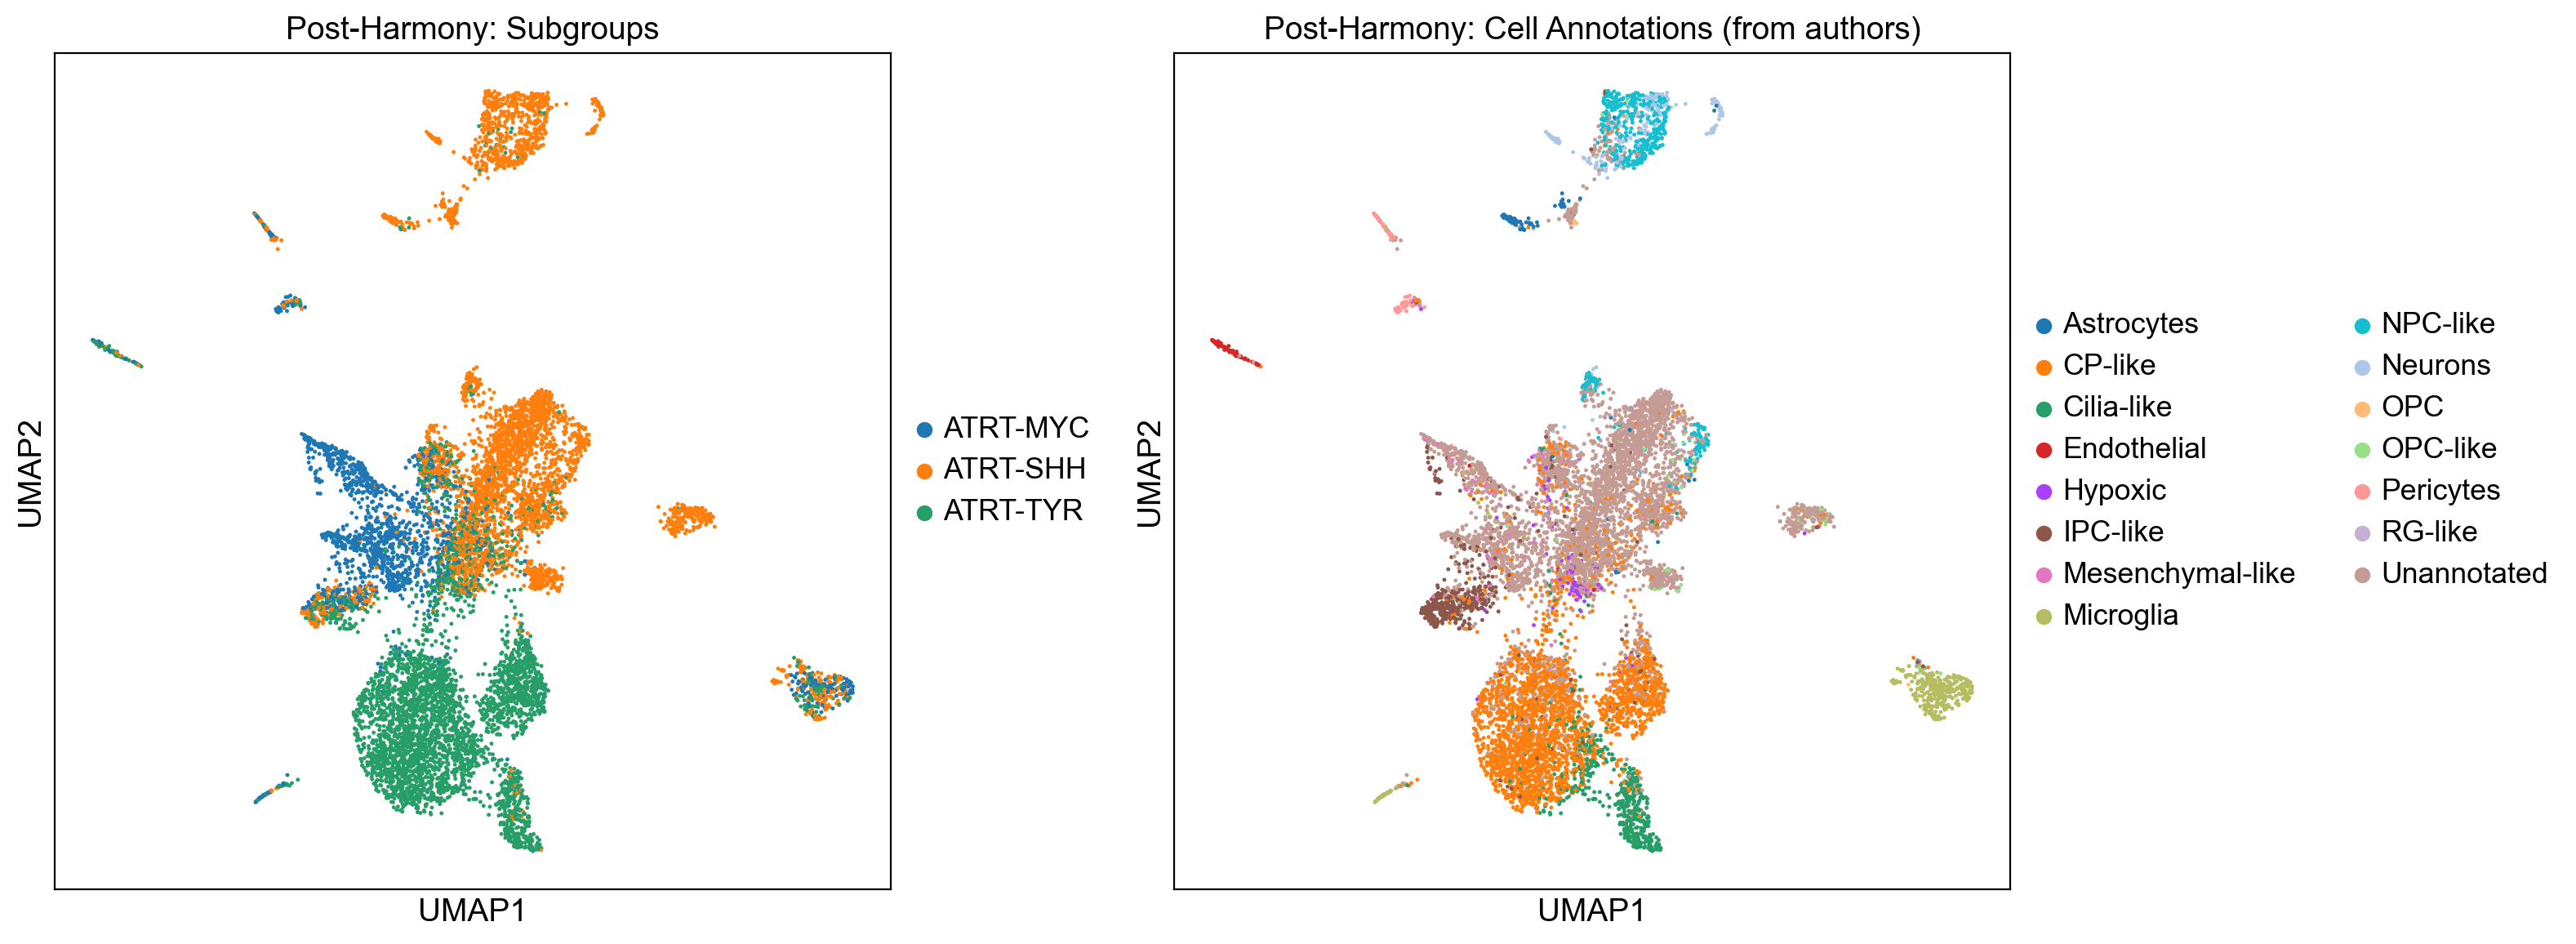


>>> Over-correction check saved
>>> Verify: Subgroups (SHH, MYC, TYR) should still show separation
>>> The authors' annotations give us a preview of cell types


In [7]:
# ============================================================
# QUALITY CHECK: Make sure Harmony didn't over-correct
# Subgroups should still separate in tumor cell clusters
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc.pl.umap(adata, color='subgroup', ax=axes[0], show=False, title='Post-Harmony: Subgroups')

# If the metadata has cell type annotations, show those too
if 'Final_Annotation' in adata.obs.columns:
    sc.pl.umap(adata, color='Final_Annotation', ax=axes[1], show=False, 
               title='Post-Harmony: Cell Annotations (from authors)')
else:
    sc.pl.umap(adata, color='Phase', ax=axes[1], show=False, title='Post-Harmony: Cell Cycle Phase')

plt.tight_layout()
plt.savefig(os.path.expanduser("~/ATRT/Data/UMAP_post_harmony_check.png"), dpi=300, bbox_inches='tight')
plt.show()

print("\n>>> Over-correction check saved")
print(">>> Verify: Subgroups (SHH, MYC, TYR) should still show separation")
print(">>> The authors' annotations give us a preview of cell types")

Cell 8 — Save:

In [8]:
# Save for Program 5 (Clustering & Cell Type Annotation)
output_path = os.path.expanduser("~/ATRT/Data/adata_harmony.h5ad")
adata.write(output_path)
print(f"Harmony-corrected AnnData saved to: {output_path}")
print(f"Shape: {adata.n_obs} nuclei x {adata.n_vars} genes")

print(f"\n>>> Program 4 complete!")
print(f">>> Key deliverables:")
print(f">>>   - Figure 2B: Elbow plot")
print(f">>>   - Figure 2B: Pre vs Post Harmony UMAP comparison")
print(f">>>   - Over-correction check plot")
print(f"\n>>> Next: Program 5 (Leiden Clustering & Cell Type Annotation)")

Harmony-corrected AnnData saved to: /Users/jacquelineli/ATRT/Data/adata_harmony.h5ad
Shape: 9604 nuclei x 36601 genes

>>> Program 4 complete!
>>> Key deliverables:
>>>   - Figure 2B: Elbow plot
>>>   - Figure 2B: Pre vs Post Harmony UMAP comparison
>>>   - Over-correction check plot

>>> Next: Program 5 (Leiden Clustering & Cell Type Annotation)
